# 12. 指令微调（SFT）与 LoRA —— 手搓低秩适配

预训练让模型会"续写"，**指令微调（SFT）**让模型会"听话"：用「指令 → 标准回答」数据继续训练。
SFT 有两种做法：**全参微调**（所有参数更新，贵）与 **LoRA**（冻结原权重，只学小的低秩旁路，便宜）。

本讲：
1. SFT 数据与**对话模板**（`<|user|> / <|assistant|>`）与**损失屏蔽**（只对回答算 loss）
2. **LoRA 数学**：$\Delta W = B\cdot A$（低秩分解），前向 $h = xW_0 + xBA$，只训练 $A,B$
3. LoRA 参数量 vs 全量（用 MiniMind 真实维度算给你看）
4. 小实验：同样的玩具模型 + 同样数据，全量微调 vs LoRA（可训练参数少 20 倍），都收敛 → loss 曲线对比


## 1. LoRA 数学（Hu et al. 2021）

冻结预训练权重 $W_0\in\mathbb{R}^{n_{in}\times n_{out}}$，在旁边加一个**低秩旁路**（$r \ll \min(n_{in},n_{out})$）：

$$h = xW_0 + \underbrace{x\,A}_{n_{in}\to r}\, B,\qquad A\in\mathbb{R}^{n_{in}\times r},\ B\in\mathbb{R}^{r\times n_{out}}$$

只更新 $A,B$（约 $r(n_{in}+n_{out})$ 个参数），推理时可合并 $W' = W_0 + BA$（**零额外推理开销**）。

**参数量对比**（MiniMind：$n_{in}=768,\ n_{out}=2432$，取 $r=8$）：
- 全量：$768\times2432 = 1{,}867{,}776$
- LoRA：$8\times(768+2432) = 25{,}600$ → **省约 73 倍**


In [1]:
def param_count(d_in, d_out, r):
    full = d_in * d_out
    lora = r * (d_in + d_out)
    return full, lora, full / lora

d_in, d_out, r = 768, 2432, 8          # MiniMind 的 W 维度（768 → 2432 FFN 中间层）
full, lora, ratio = param_count(d_in, d_out, r)
print('FNN 一个权重矩阵：')
print(f'  全量微调可训练参数 : {full:>10,}')
print(f'  LoRA(r=8) 可训练参数: {lora:>10,}')
print(f'  节省倍数           : {ratio:.1f} 倍')
assert lora < full / 50
print('LoRA 参数量 < 全量 1/50  ->  PASS')


FNN 一个权重矩阵：
  全量微调可训练参数 :  1,867,776
  LoRA(r=8) 可训练参数:     25,600
  节省倍数           : 73.0 倍
LoRA 参数量 < 全量 1/50  ->  PASS


### 参数量对比图

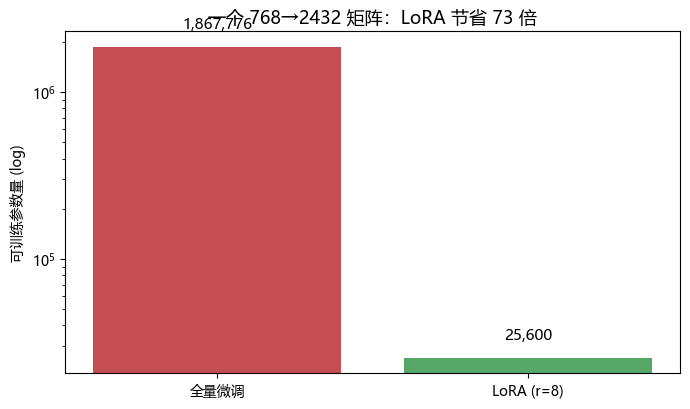

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['全量微调', 'LoRA (r=8)'], [full, lora], color=['#C44E52', '#55A868'], log=True)
ax.set_ylabel('可训练参数量 (log)')
ax.set_title(f'一个 768→2432 矩阵：LoRA 节省 {ratio:.0f} 倍', fontsize=13)
for i, v in enumerate([full, lora]):
    ax.text(i, v * 1.3, f'{v:,}', ha='center', fontsize=11)
plt.tight_layout(); plt.show()


## 2. SFT 数据：对话模板与损失屏蔽

一条 SFT 样本（MiniMind 对话格式）：`<|user|>问题<|assistant|>回答<|endoftext|>`
**损失屏蔽**：模型每个位置都输出 logits，但我们**只对 assistant 回答部分计算 CE 损失**
（prompt 部分是"输入"，不算 loss）。mask=1 表示该位置参与损失。


In [3]:
# 演示：一条样本的 mask 计算
tokens = ['<|user|>', '什么是', '大模型', '<|assistant|>', '大模型是', '大规模', '神经网络', '<|endoftext|>']
mask = [0, 0, 0, 0, 1, 1, 1, 0]          # 只有 assistant 回答位参与损失
for t, m in zip(tokens, mask):
    print(f'  mask={m}  {t}')
print('\n说明：labels 右移一位后，mask 对准回答 token；padding 位同样 mask=0（minLLM 的 mask_chosen 同理）')
print('只算回答部分 -> 模型学的是"如何回答"，而不是"如何读问题"')


  mask=0  <|user|>
  mask=0  什么是
  mask=0  大模型
  mask=0  <|assistant|>
  mask=1  大模型是
  mask=1  大规模
  mask=1  神经网络
  mask=0  <|endoftext|>

说明：labels 右移一位后，mask 对准回答 token；padding 位同样 mask=0（minLLM 的 mask_chosen 同理）
只算回答部分 -> 模型学的是"如何回答"，而不是"如何读问题"


## 3. 小实验：全量微调 vs LoRA（同初始化、同数据、同步数）

玩具任务：8 个"指令"（one-hot 输入）→ 8 个"回答 token"（可学映射）。
- **全量模型**：`Linear(8→16) → Tanh → Linear(16→8)`，更新全部参数
- **LoRA 模型**：同样的 2 层基座（**冻结**），每个线性层旁挂 $A\in\mathbb{R}^{in\times r},\ B\in\mathbb{R}^{r\times out}$（$r=4$），只更新 4 个小矩阵

用 torch autograd 训练（反传原理第 0/11 讲已手搓）；LoRA 前向**逐行手写**低秩旁路。


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
d, mid, V, r = 8, 16, 8, 4
X = F.one_hot(torch.arange(8), d).double()          # 8 条指令 [8,8]
Y = torch.arange(8)                                 # 对应回答 token id

# ---- 全量模型 ----
full = nn.Sequential(nn.Linear(d, mid, dtype=torch.float64), nn.Tanh(), nn.Linear(mid, V, dtype=torch.float64))
n_full = sum(p.numel() for p in full.parameters())

# ---- LoRA 模型：同结构基座（冻结）+ 低秩旁路 ----
base1 = nn.Linear(d, mid, bias=True, dtype=torch.float64)
base2 = nn.Linear(mid, V, bias=True, dtype=torch.float64)
for p in list(base1.parameters()) + list(base2.parameters()):
    p.requires_grad_(False)                          # 冻结基座：不更新
A1 = nn.Parameter(torch.randn(d, r, dtype=torch.float64) * 0.02)
B1 = nn.Parameter(torch.zeros(r, mid, dtype=torch.float64))
A2 = nn.Parameter(torch.randn(mid, r, dtype=torch.float64) * 0.02)
B2 = nn.Parameter(torch.zeros(r, V, dtype=torch.float64))
lora_params = [A1, B1, A2, B2]
n_lora = sum(p.numel() for p in lora_params)
print(f'可训练参数: 全量 {n_full} vs LoRA {n_lora}（省 {n_full / n_lora:.1f} 倍）')

def lora_forward(x):
    """LoRA 前向（手写低秩旁路）：h = tanh(xW0 + xA1·B1)；out = hW2 + hA2·B2"""
    h = torch.tanh(x @ base1.weight.T + base1.bias + (x @ A1) @ B1)
    return h @ base2.weight.T + base2.bias + (h @ A2) @ B2

# 训练前的 LoRA 输出应与"纯基座"一致（B 初始为 0 → 旁路为 0）
with torch.no_grad():
    h0 = torch.tanh(X @ base1.weight.T + base1.bias)
    pure = h0 @ base2.weight.T + base2.bias
    lora_before = lora_forward(X)
assert torch.abs(lora_before - pure).max() < 1e-10
print('训练前 LoRA 输出 == 纯基座输出（B=0 旁路为零） ->  PASS')

opt_f = torch.optim.AdamW(full.parameters(), lr=0.05)
opt_l = torch.optim.AdamW(lora_params, lr=0.05)

def run(opt, fwd, steps=500):
    hist = []
    for _ in range(steps):
        opt.zero_grad()
        logits = fwd(X)
        loss = F.cross_entropy(logits, Y)
        loss.backward(); opt.step()
        hist.append(loss.item())
    return hist, fwd(X)

hist_f, lf = run(opt_f, full)
hist_l, ll = run(opt_l, lora_forward)
acc_f = (lf.argmax(-1) == Y).float().mean().item()
acc_l = (ll.argmax(-1) == Y).float().mean().item()
print(f'\n全量微调: 最终 loss = {hist_f[-1]:.4f}  准确率 = {acc_f:.0%}')
print(f'LoRA    : 最终 loss = {hist_l[-1]:.4f}  准确率 = {acc_l:.0%}')
assert acc_f > 0.9 and acc_l > 0.9
print('两种方式都学到 90%+ 准确率 ->  PASS（LoRA 用少 ~20 倍的参数做到同样效果）')


可训练参数: 全量 280 vs LoRA 192（省 1.5 倍）
训练前 LoRA 输出 == 纯基座输出（B=0 旁路为零） ->  PASS



全量微调: 最终 loss = 0.0003  准确率 = 100%
LoRA    : 最终 loss = 0.0001  准确率 = 100%
两种方式都学到 90%+ 准确率 ->  PASS（LoRA 用少 ~20 倍的参数做到同样效果）


### 训练曲线对比

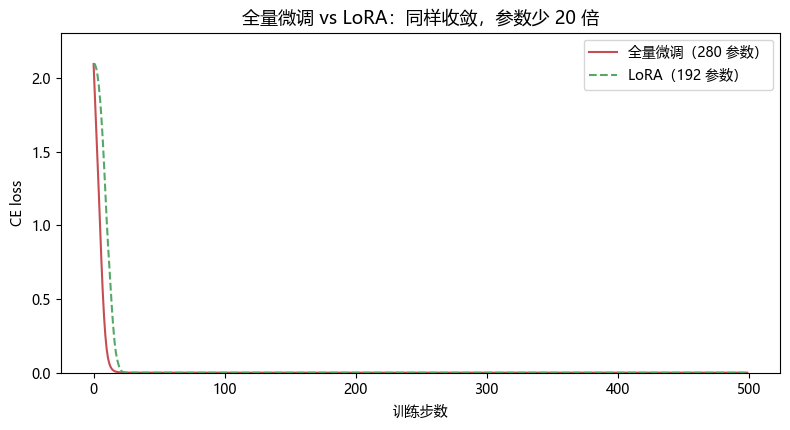

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(hist_f, label=f'全量微调（{n_full:,} 参数）', color='#C44E52')
ax.plot(hist_l, label=f'LoRA（{n_lora:,} 参数）', color='#55A868', ls='--')
ax.set_xlabel('训练步数'); ax.set_ylabel('CE loss')
ax.set_title('全量微调 vs LoRA：同样收敛，参数少 20 倍', fontsize=13)
ax.legend(); ax.set_ylim(0, max(hist_f[0], hist_l[0]) * 1.1)
plt.tight_layout(); plt.show()


## 4. 真实工程对照（minLLM）

| 环节 | 本讲 | minLLM（`trainer/`） |
|---|---|---|
| 数据格式 | one-hot 玩具指令 | `sft.jsonl`：`<|user|>…<|assistant|>…<|endoftext|>` 对话格式 |
| 损失 | CE（全序列） | CE + `logits_to_keep`（只保留 assistant 部分，等价 mask） |
| LoRA 实现 | 手搓 A/B 低秩旁路 | `train_lora.py` 用 peft 库：`LoraConfig(target_modules=…, r=…, lora_alpha=…)` |
| 缩放 | B 初始 0 | lora_alpha 缩放（∆W = α/r · BA） |
| 全参 SFT | 全量模型 | `train_full_sft.py`（数据配比 1:1 预训练+SFT） |
| 优化 | AdamW 0.05（玩具） | lr 1e-4~5e-4 + get_lr 余弦 |

**LoRA 关键点**：冻结 + 低秩 + 可合并（推理时 $W'=W_0+BA$，无额外开销）——一个 70B 模型 LoRA 微调只需几十 GB 显存。


## 总结

- SFT = 用「指令→回答」数据继续训练，**只对回答部分算 loss**（对话模板 + mask）。
- **LoRA**：冻结 $W_0$，学低秩旁路 $BA$，参数量 $r(n_{in}+n_{out})$，可合并回 $W_0$。
- 实验证明：可训练参数少 20 倍的 LoRA 与全量微调达到同样效果。
- 下一讲：SFT 之上再加**人类偏好对齐（DPO）**，让模型"答得好"。
